# Traffic Violation Dataset - Exploratory Data Analysis



## 1. Setup


In [26]:
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:,.3f}'.format)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_PATH = Path('dataset.csv')
assert DATA_PATH.exists(), f'Missing file: {DATA_PATH}'
print(f'Dataset path: {DATA_PATH.resolve()}')


Dataset path: /home/saumya/sems/td/hackathon/flipkartgridlock2/round2/dataset.csv


## 2. Load Data

The CSV is loaded read-only. No cell writes back to `dataset.csv`.


In [27]:
df = pd.read_csv(DATA_PATH)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')
display(df.head())


Rows: 298,450
Columns: 24


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,closed_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.926,77.619,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,NaN,2023-11-28 04:48:04.582978+00,FKDEV00000,FKUSR00000,9.000,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905,77.701,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,NaN,2023-11-24 23:00:24.115257+00,FKDEV00001,FKUSR00001,82.000,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925,77.619,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,NaN,2023-11-28 04:47:02.33776+00,FKDEV00000,FKUSR00000,9.000,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.957,77.519,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,NaN,2023-11-18 04:46:57.216868+00,FKDEV00002,FKUSR00002,26.000,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.978,77.581,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,NaN,2023-11-28 02:44:50.46737+00,FKDEV00003,FKUSR00003,3.000,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


## 3. First Look


In [28]:
display(df.tail())

overview = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null': df.notna().sum().values,
    'null_count': df.isna().sum().values,
    'null_pct': (df.isna().mean() * 100).round(2).values,
    'unique_values': df.nunique(dropna=True).values,
})
overview['unique_pct'] = (overview['unique_values'] / len(df) * 100).round(2)
display(overview)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,closed_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
298445,FKID298445,13.042,77.613,"MBT Road, Govind Pura, Nagavara, Bengaluru, Ka...",FKN00GL233057,VAN,NaN,"[""WRONG PARKING""]",[112],2023-12-19 04:12:46+00,NaN,2023-12-19 04:52:48.013448+00,FKDEV01640,FKUSR01541,46.000,K.G. Halli,True,No Junction,NaN,NaN,FKN00GL233057,VAN,rejected,2023-12-19 20:20:02.271+00
298446,FKID298446,12.977,77.576,"Subedar Chatram Road, RK Puram, Gandhi Nagar, ...",FKN00GL233058,PASSENGER AUTO,NaN,"[""WRONG PARKING""]",[112],2023-11-28 07:59:46+00,NaN,2023-11-28 08:01:41.308193+00,FKDEV00093,FKUSR00094,3.000,Upparpet,True,BTP040 - Elite Junction,NaN,NaN,FKN00GL233058,PASSENGER AUTO,rejected,2023-11-30 04:09:35.6+00
298447,FKID298447,12.964,77.577,"KR Market Bus Terminus, BGS Flyover, Dharmaray...",FKN00GL233059,MOTOR CYCLE,NaN,"[""WRONG PARKING""]",[112],2023-11-19 20:12:46+00,NaN,2023-11-20 01:51:48.309949+00,FKDEV00392,FKUSR00388,28.000,City Market,False,BTP082 - KR Market Junction,NaN,NaN,NaN,NaN,NaN,NaN
298448,FKID298448,12.907,77.696,"Sarjapura Main Road, Doddakannelli Circle, Dod...",FKN00GL233060,MAXI-CAB,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,NaN,2023-11-24 23:00:23.159505+00,FKDEV00001,FKUSR00001,82.000,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
298449,FKID298449,12.957,77.704,"HAL Airport Road, SJR Spencer, Ashwath Nagar, ...",FKN00GL233061,SCOOTER,NaN,"[""WRONG PARKING""]",[112],2024-03-14 22:17:46+00,NaN,2024-03-14 23:23:41.734268+00,FKDEV00078,FKUSR00078,13.000,HAL Old Airport,True,No Junction,NaN,2024-04-01 17:59:14.801141+00,FKN00GL233061,SCOOTER,approved,2024-04-15 20:36:01.108+00


,column,dtype,non_null,null_count,null_pct,unique_values,unique_pct
0,id,str,298450,0,0.000,298450,100.000
1,latitude,float64,298450,0,0.000,177982,59.640
2,longitude,float64,298450,0,0.000,177378,59.430
3,location,str,295409,3041,1.020,10942,3.670
4,vehicle_number,str,298450,0,0.000,231890,77.700
5,vehicle_type,str,298450,0,0.000,22,0.010
6,description,float64,0,298450,100.000,0,0.000
7,violation_type,str,298450,0,0.000,991,0.330
8,offence_code,str,298450,0,0.000,991,0.330
9,created_datetime,str,298450,0,0.000,94417,31.640


In [29]:
print('Dataset memory usage:')
print(f'{df.memory_usage(deep=True).sum() / 1024**2:,.2f} MB')

print('\nDuplicate full rows:')
print(f'{df.duplicated().sum():,}')

if 'id' in df.columns:
    print('\nDuplicate IDs:')
    print(f'{df["id"].duplicated().sum():,}')


Dataset memory usage:
134.75 MB

Duplicate full rows:
0

Duplicate IDs:
0


## 4. Missing Values


,missing_count,missing_pct
description,298450,100.000
closed_datetime,298450,100.000
action_taken_timestamp,298450,100.000
data_sent_to_scita_timestamp,256289,85.870
updated_vehicle_type,125254,41.970
validation_timestamp,125254,41.970
validation_status,125254,41.970
updated_vehicle_number,125254,41.970
center_code,11260,3.770
location,3041,1.020


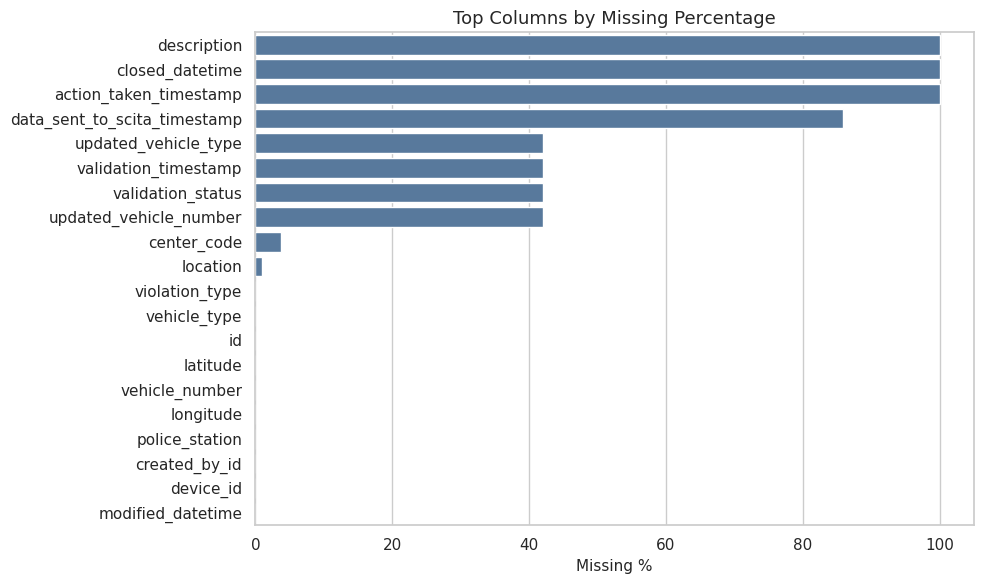

In [30]:
missing = (
    df.isna().sum()
      .to_frame('missing_count')
      .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
      .sort_values('missing_pct', ascending=False)
)
display(missing)

plt.figure(figsize=(10, 6))
sns.barplot(data=missing.reset_index().rename(columns={'index': 'column'}).head(20),
            x='missing_pct', y='column', color='#4C78A8')
plt.title('Top Columns by Missing Percentage')
plt.xlabel('Missing %')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 5. Type Conversion for EDA

Create an in-memory copy and parse datetime/list-like columns for analysis. This does not modify the CSV.


In [31]:
df_eda = df.copy()

# Normalize common NULL string placeholders into true missing values in object columns.
object_cols = df_eda.select_dtypes(include='object').columns
for col in object_cols:
    df_eda[col] = df_eda[col].replace({'NULL': np.nan, 'null': np.nan, '': np.nan})

datetime_cols = [
    'created_datetime', 'closed_datetime', 'modified_datetime',
    'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'validation_timestamp'
]
for col in datetime_cols:
    if col in df_eda.columns:
        df_eda[col] = pd.to_datetime(df_eda[col], errors='coerce', utc=True)

def parse_list_cell(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, list) else [parsed]
    except (ValueError, SyntaxError):
        return [value]

for col in ['violation_type', 'offence_code']:
    if col in df_eda.columns:
        df_eda[f'{col}_list'] = df_eda[col].apply(parse_list_cell)
        df_eda[f'{col}_count'] = df_eda[f'{col}_list'].str.len()

if 'created_datetime' in df_eda.columns:
    df_eda['created_date'] = df_eda['created_datetime'].dt.date
    df_eda['created_hour'] = df_eda['created_datetime'].dt.hour
    df_eda['created_day_name'] = df_eda['created_datetime'].dt.day_name()
    df_eda['created_month'] = df_eda['created_datetime'].dt.to_period('M').astype(str)

print('Converted dtypes:')
display(df_eda.dtypes.to_frame('dtype'))


Converted dtypes:


,dtype
id,str
latitude,float64
longitude,float64
location,str
vehicle_number,str
vehicle_type,str
description,float64
violation_type,str
offence_code,str
created_datetime,"datetime64[us, UTC]"


## 6. Numeric Feature Summary


Numeric columns: ['latitude', 'longitude', 'description', 'center_code', 'violation_type_count', 'offence_code_count', 'created_hour']


,count,mean,std,min,25%,50%,75%,max
latitude,"298,450.000",12.981,0.050,12.803,12.963,12.977,12.997,13.294
longitude,"298,450.000",77.601,0.051,77.443,77.571,77.584,77.622,77.772
description,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
center_code,"287,190.000",23.023,20.006,2.000,11.000,17.000,29.000,88.000
violation_type_count,"298,450.000",1.168,0.485,1.000,1.000,1.000,1.000,12.000
offence_code_count,"298,450.000",1.168,0.485,1.000,1.000,1.000,1.000,12.000
created_hour,"298,445.000",9.203,8.288,0.000,3.000,5.000,20.000,23.000


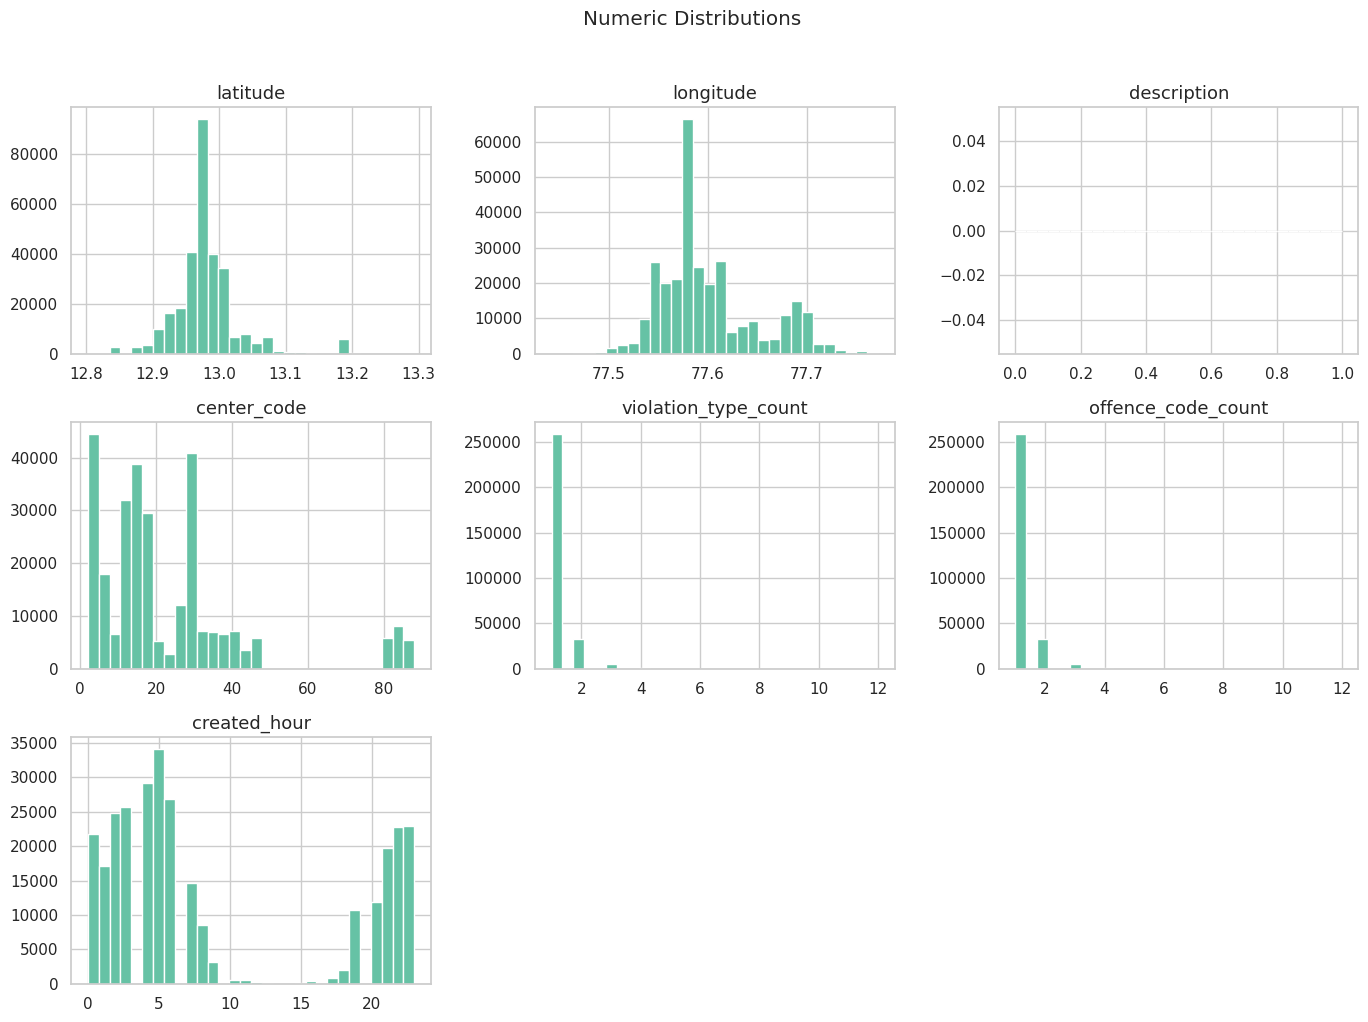

In [32]:
num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
print(f'Numeric columns: {num_cols}')

display(df_eda[num_cols].describe().T)

if num_cols:
    df_eda[num_cols].hist(figsize=(14, 10), bins=30, edgecolor='white')
    plt.suptitle('Numeric Distributions', y=1.02)
    plt.tight_layout()
    plt.show()


## 7. Categorical Feature Summary


In [33]:
cat_cols = df_eda.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
cat_summary = []
for col in cat_cols:
    cat_summary.append({
        'column': col,
        'unique_values': df_eda[col].nunique(dropna=True),
        'top_value': df_eda[col].mode(dropna=True).iloc[0] if not df_eda[col].mode(dropna=True).empty else np.nan,
        'top_count': df_eda[col].value_counts(dropna=True).iloc[0] if not df_eda[col].value_counts(dropna=True).empty else 0,
    })
cat_summary = pd.DataFrame(cat_summary).sort_values('unique_values', ascending=False)
display(cat_summary)

for col in ['vehicle_type', 'updated_vehicle_type', 'validation_status', 'police_station', 'junction_name', 'data_sent_to_scita']:
    if col in df_eda.columns:
        print()
        print(f'Top values for {col}:')
        display(df_eda[col].value_counts(dropna=False).head(15).to_frame('count'))


TypeError: unhashable type: 'list'

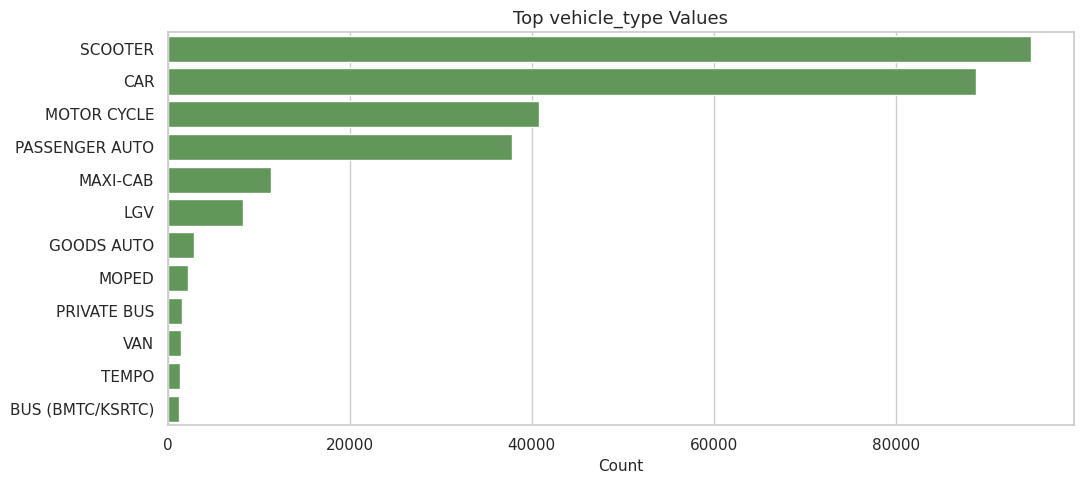

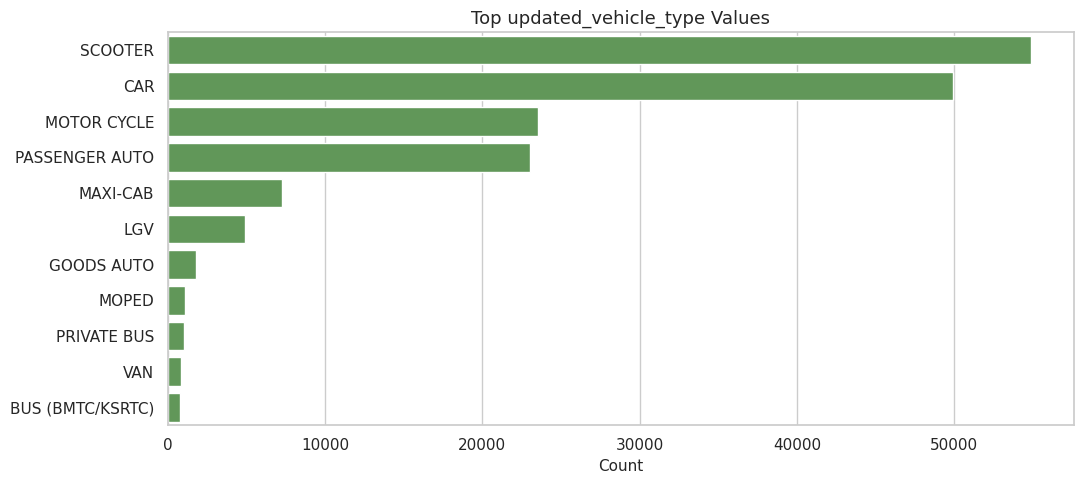

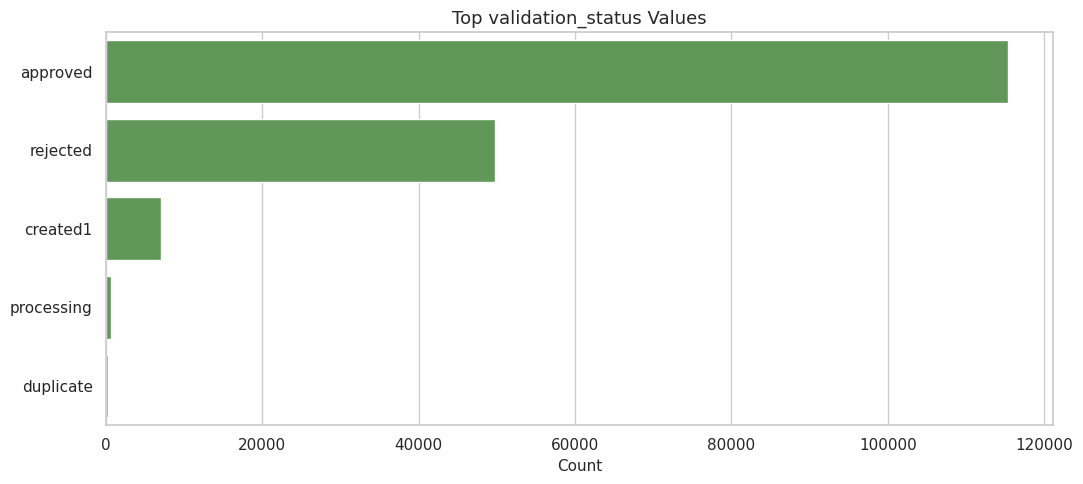

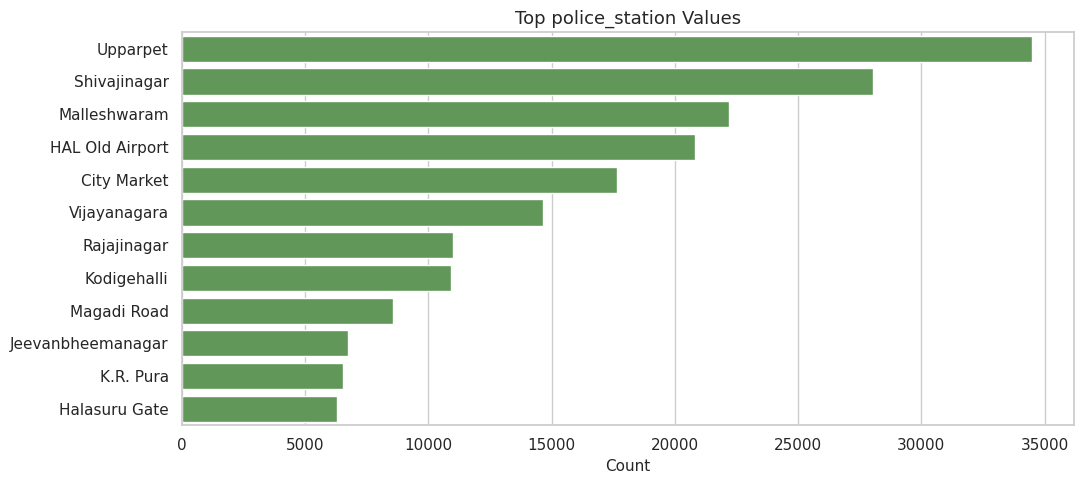

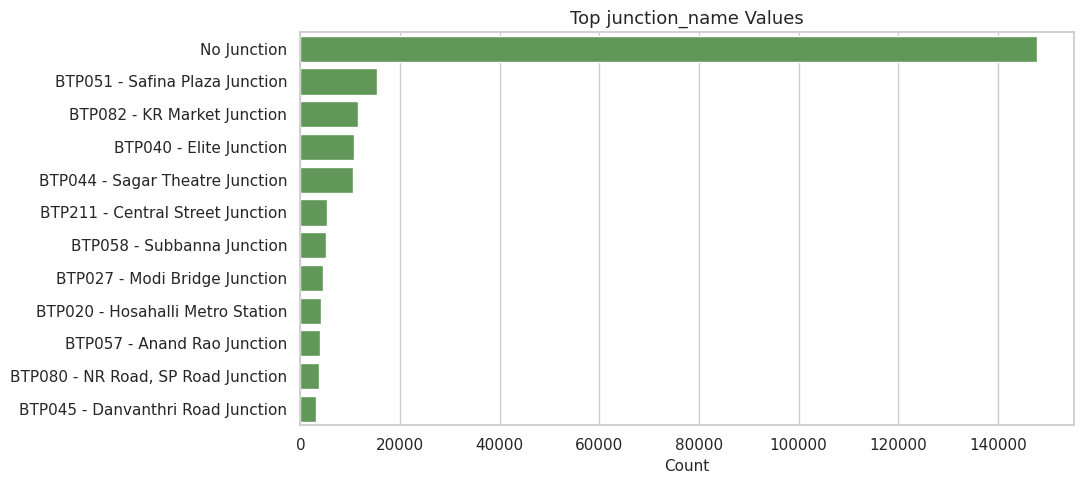

In [34]:
plot_cols = ['vehicle_type', 'updated_vehicle_type', 'validation_status', 'police_station', 'junction_name']
for col in plot_cols:
    if col in df_eda.columns:
        top = df_eda[col].value_counts(dropna=False).head(12).reset_index()
        top.columns = [col, 'count']
        top[col] = top[col].astype(str)
        plt.figure(figsize=(11, 5))
        sns.barplot(data=top, x='count', y=col, color='#59A14F')
        plt.title(f'Top {col} Values')
        plt.xlabel('Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()


## 8. Violation and Offence Analysis


,violation_type,count
0,WRONG PARKING,164977
1,NO PARKING,139050
2,PARKING IN A MAIN ROAD,23943
3,DEFECTIVE NUMBER PLATE,7848
4,PARKING ON FOOTPATH,3757
5,PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC,2403
6,DOUBLE PARKING,2037
7,PARKING NEAR ROAD CROSSING,1687
8,REFUSE TO GO FOR HIRE,887
9,PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS,525


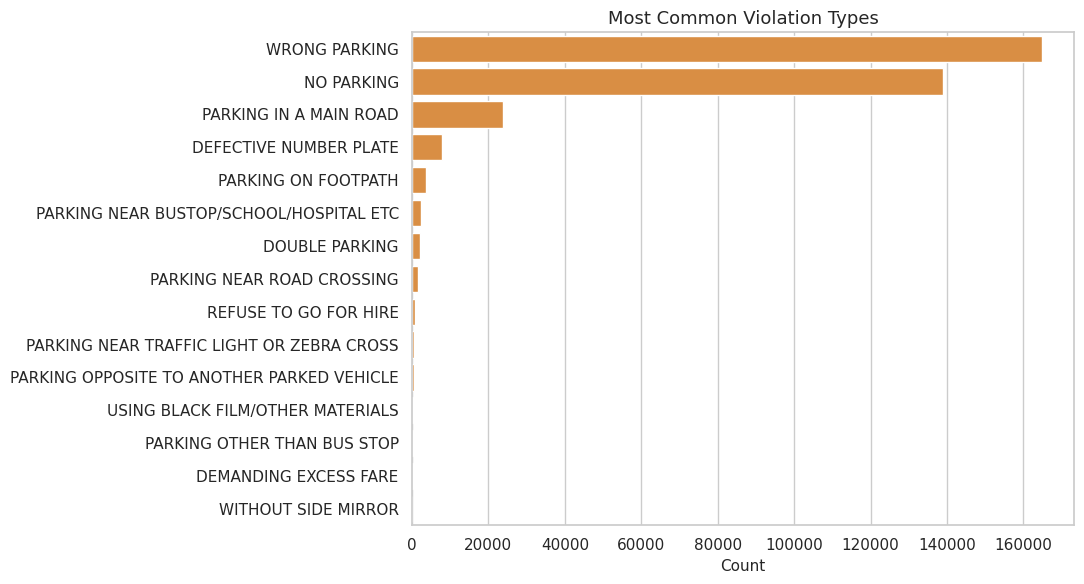

,offence_code,count
0,112,164977
1,113,139050
2,107,23943
3,116,7848
4,105,3757
5,111,2403
6,109,2037
7,104,1687
8,124,887
9,106,525


In [35]:
if 'violation_type_list' in df_eda.columns:
    violations = df_eda.explode('violation_type_list')
    violation_counts = violations['violation_type_list'].value_counts().rename_axis('violation_type').reset_index(name='count')
    display(violation_counts.head(30))

    plt.figure(figsize=(11, 6))
    sns.barplot(data=violation_counts.head(15), x='count', y='violation_type', color='#F28E2B')
    plt.title('Most Common Violation Types')
    plt.xlabel('Count')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

if 'offence_code_list' in df_eda.columns:
    offence_counts = df_eda.explode('offence_code_list')['offence_code_list'].value_counts().rename_axis('offence_code').reset_index(name='count')
    display(offence_counts.head(30))


,vehicle_type,violation_type_list,count
221,SCOOTER,WRONG PARKING,52839
25,CAR,WRONG PARKING,46401
16,CAR,NO PARKING,44468
209,SCOOTER,NO PARKING,43122
149,MOTOR CYCLE,WRONG PARKING,21585
174,PASSENGER AUTO,WRONG PARKING,21424
139,MOTOR CYCLE,NO PARKING,19852
164,PASSENGER AUTO,NO PARKING,17212
18,CAR,PARKING IN A MAIN ROAD,9441
87,LGV,WRONG PARKING,5870


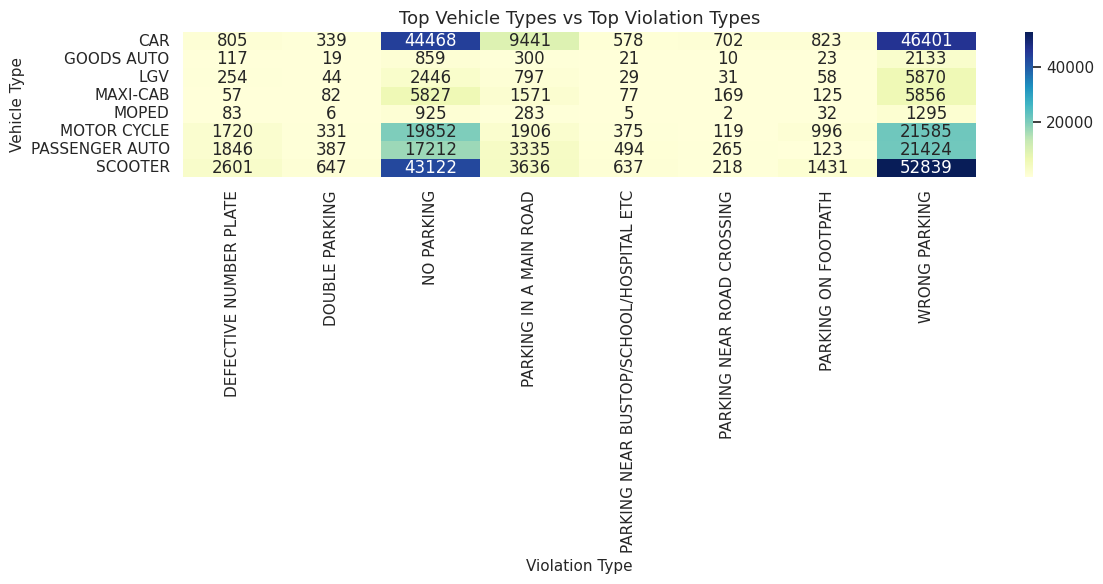

In [36]:
if {'vehicle_type', 'violation_type_list'}.issubset(df_eda.columns):
    vehicle_violation = (
        df_eda.explode('violation_type_list')
              .groupby(['vehicle_type', 'violation_type_list'])
              .size()
              .reset_index(name='count')
              .sort_values('count', ascending=False)
    )
    display(vehicle_violation.head(30))

    pivot = vehicle_violation.pivot_table(index='vehicle_type', columns='violation_type_list', values='count', fill_value=0)
    top_vehicle_types = df_eda['vehicle_type'].value_counts().head(8).index
    top_violations = df_eda.explode('violation_type_list')['violation_type_list'].value_counts().head(8).index
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot.loc[pivot.index.intersection(top_vehicle_types), pivot.columns.intersection(top_violations)],
                cmap='YlGnBu', annot=True, fmt='.0f')
    plt.title('Top Vehicle Types vs Top Violation Types')
    plt.xlabel('Violation Type')
    plt.ylabel('Vehicle Type')
    plt.tight_layout()
    plt.show()


## 9. Time-Based Analysis


Created datetime range:
2023-11-09 19:11:46+00:00 to 2024-04-08 17:30:46+00:00


,count
count,152.000
mean,"1,963.454"
std,377.937
min,153.000
25%,"1,757.500"
50%,"1,956.000"
75%,"2,193.000"
max,"2,858.000"


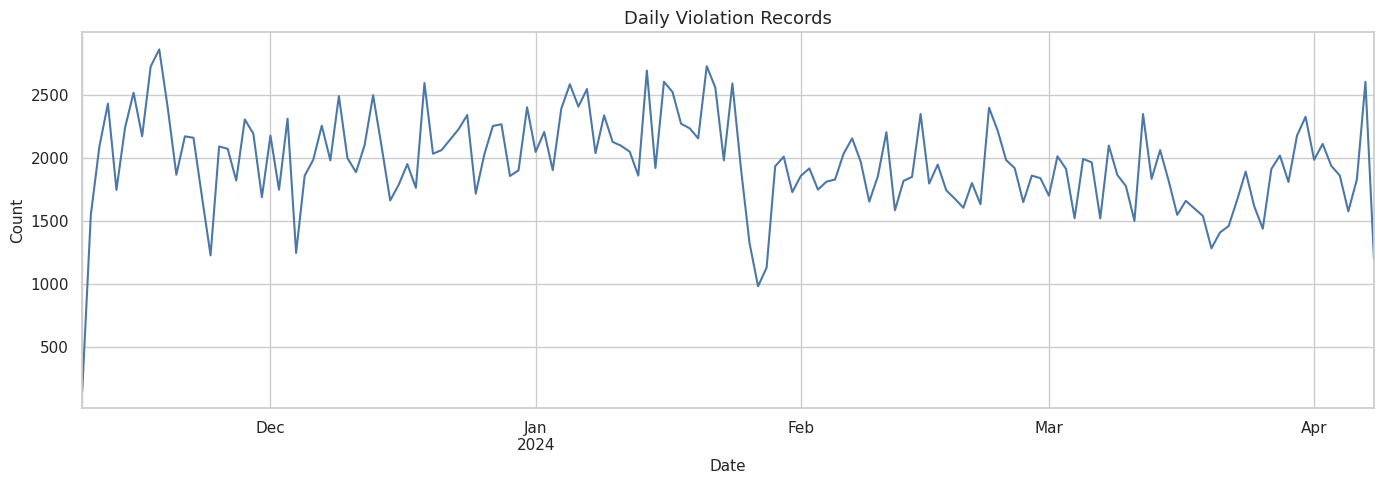

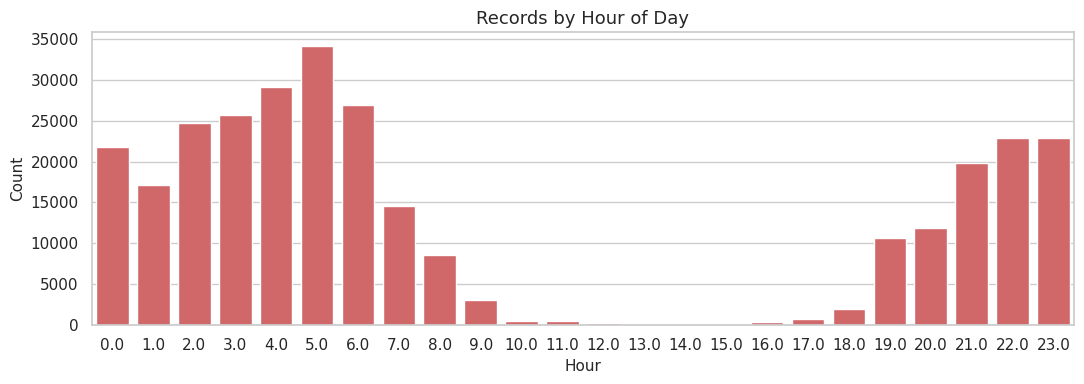

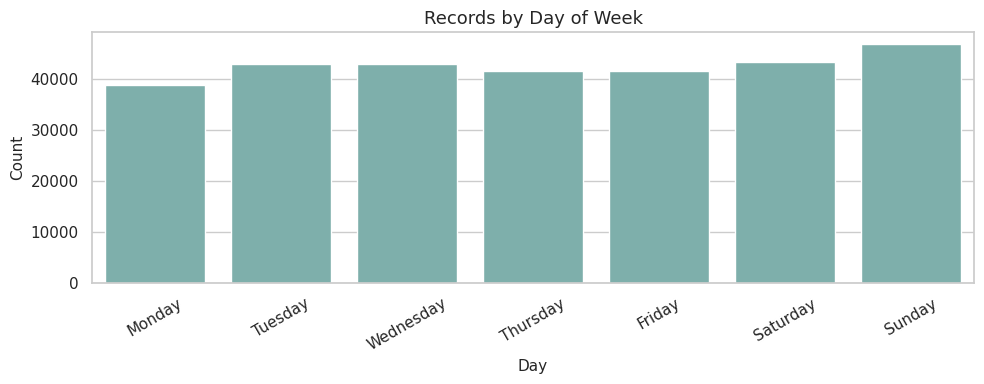

In [37]:
if 'created_datetime' in df_eda.columns:
    print('Created datetime range:')
    print(df_eda['created_datetime'].min(), 'to', df_eda['created_datetime'].max())

    daily_counts = df_eda.set_index('created_datetime').resample('D').size().rename('count')
    display(daily_counts.describe().to_frame())

    plt.figure(figsize=(14, 5))
    daily_counts.plot(color='#4C78A8')
    plt.title('Daily Violation Records')
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    hour_counts = df_eda['created_hour'].value_counts().sort_index()
    plt.figure(figsize=(11, 4))
    sns.barplot(x=hour_counts.index, y=hour_counts.values, color='#E15759')
    plt.title('Records by Hour of Day')
    plt.xlabel('Hour')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df_eda['created_day_name'].value_counts().reindex(day_order)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=day_counts.index, y=day_counts.values, color='#76B7B2')
    plt.title('Records by Day of Week')
    plt.xlabel('Day')
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 10. Location and Police Station Analysis


In [38]:
for col in ['police_station', 'center_code', 'junction_name']:
    if col in df_eda.columns:
        print()
        print(f'Top records by {col}:')
        display(df_eda[col].value_counts(dropna=False).head(20).to_frame('count'))

if {'police_station', 'validation_status'}.issubset(df_eda.columns):
    station_status = pd.crosstab(df_eda['police_station'], df_eda['validation_status'], normalize='index') * 100
    top_stations = df_eda['police_station'].value_counts().head(15).index
    display(station_status.loc[top_stations].round(2))



Top records by police_station:


,count
police_station,
Upparpet,34468
Shivajinagar,28044
Malleshwaram,22200
HAL Old Airport,20819
City Market,17646
Vijayanagara,14652
Rajajinagar,10998
Kodigehalli,10916
Magadi Road,8558



Top records by center_code:


,count
center_code,
3.000,34468
16.000,28044
19.000,22200
13.000,20819
28.000,17646
30.000,14652
NaN,11260
6.000,10998
29.000,8558



Top records by junction_name:


,count
junction_name,
No Junction,147880
BTP051 - Safina Plaza Junction,15449
BTP082 - KR Market Junction,11538
BTP040 - Elite Junction,10718
BTP044 - Sagar Theatre Junction,10549
BTP211 - Central Street Junction,5388
BTP058 - Subbanna Junction,5189
BTP027 - Modi Bridge Junction,4584
BTP020 - Hosahalli Metro Station,4101


validation_status,approved,created1,duplicate,processing,rejected
police_station,,,,,
Upparpet,73.170,3.500,0.190,0.330,22.800
Shivajinagar,62.790,4.340,0.310,0.310,32.250
Malleshwaram,69.970,4.010,0.290,0.300,25.440
HAL Old Airport,63.740,5.570,0.250,0.620,29.820
City Market,64.010,4.620,0.170,0.430,30.780
Vijayanagara,65.610,2.360,0.200,0.290,31.530
Rajajinagar,66.410,2.420,0.130,0.150,30.890
Kodigehalli,56.420,3.240,0.000,0.460,39.880
Magadi Road,62.570,4.640,0.230,0.270,32.290


In [ ]:
if {'latitude', 'longitude'}.issubset(df_eda.columns):
    coord_summary = df_eda[['latitude', 'longitude']].describe().T
    display(coord_summary)

    sample_size = min(5000, len(df_eda))
    geo_sample = df_eda.dropna(subset=['latitude', 'longitude']).sample(sample_size, random_state=42)

    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=geo_sample, x='longitude', y='latitude', hue='vehicle_type' if 'vehicle_type' in df_eda.columns else None,
                    alpha=0.45, s=18, linewidth=0)
    plt.title(f'Geographic Spread of Records (sample n={len(geo_sample):,})')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Vehicle Type')
    plt.tight_layout()
    plt.show()


## 11. Validation and Processing Behaviour


,validation_status,count,pct
0,NaN,125254,41.970
1,approved,115400,38.670
2,rejected,49754,16.670
3,created1,7044,2.360
4,processing,678,0.230
5,duplicate,320,0.110


Validation delay records: 173,030


,validation_delay_hours
count,"173,030.000"
mean,96.779
std,216.158
min,-14.665
25%,19.289
50%,31.042
75%,70.730
90%,164.895
95%,549.093
max,"3,664.265"


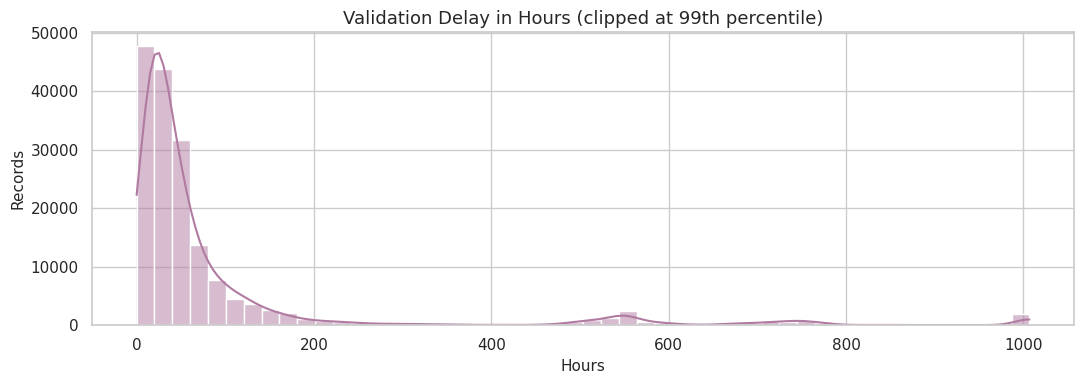

In [39]:
if 'validation_status' in df_eda.columns:
    validation_counts = df_eda['validation_status'].value_counts(dropna=False).rename_axis('validation_status').reset_index(name='count')
    validation_counts['pct'] = (validation_counts['count'] / len(df_eda) * 100).round(2)
    display(validation_counts)

if {'created_datetime', 'validation_timestamp'}.issubset(df_eda.columns):
    df_eda['validation_delay_hours'] = (df_eda['validation_timestamp'] - df_eda['created_datetime']).dt.total_seconds() / 3600
    delay = df_eda['validation_delay_hours'].dropna()
    print(f'Validation delay records: {len(delay):,}')
    display(delay.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame('validation_delay_hours'))

    plt.figure(figsize=(11, 4))
    sns.histplot(delay.clip(lower=0, upper=delay.quantile(0.99)), bins=50, kde=True, color='#B07AA1')
    plt.title('Validation Delay in Hours (clipped at 99th percentile)')
    plt.xlabel('Hours')
    plt.ylabel('Records')
    plt.tight_layout()
    plt.show()


## 12. Relationship Checks


,latitude,longitude,description,center_code,violation_type_count,offence_code_count,created_hour,validation_delay_hours
latitude,1.000,-0.072,NaN,-0.022,-0.018,-0.018,0.025,-0.015
longitude,-0.072,1.000,NaN,0.164,0.225,0.225,0.050,0.018
description,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
center_code,-0.022,0.164,NaN,1.000,0.079,0.079,0.036,0.017
violation_type_count,-0.018,0.225,NaN,0.079,1.000,1.000,0.026,0.039
offence_code_count,-0.018,0.225,NaN,0.079,1.000,1.000,0.026,0.039
created_hour,0.025,0.050,NaN,0.036,0.026,0.026,1.000,0.037
validation_delay_hours,-0.015,0.018,NaN,0.017,0.039,0.039,0.037,1.000


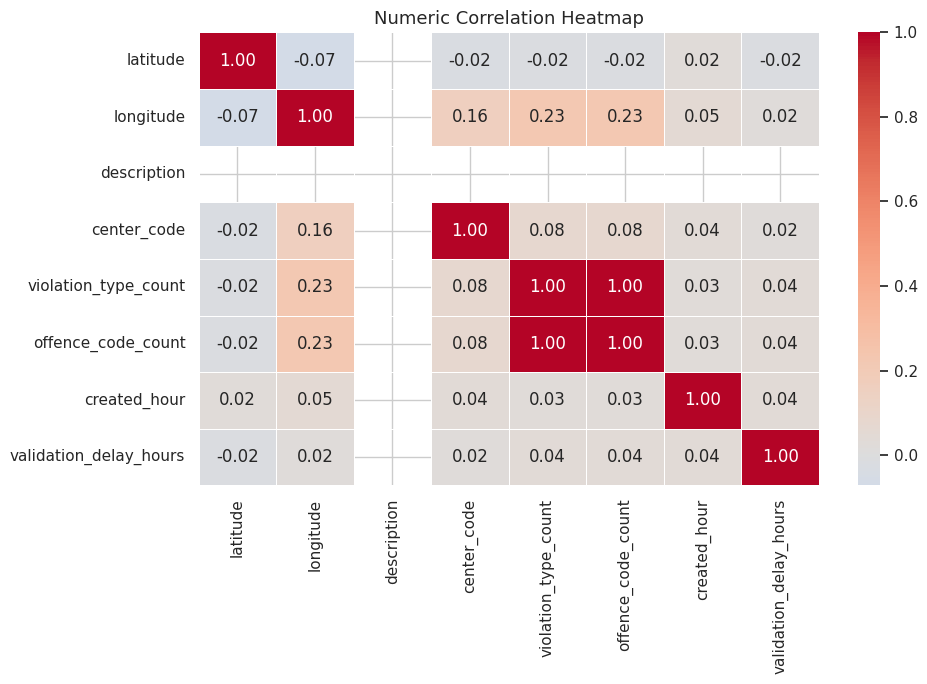

,feature_1,feature_2,abs_corr
37,violation_type_count,offence_code_count,1.000


In [40]:
numeric_for_corr = df_eda.select_dtypes(include=np.number).columns.tolist()
if len(numeric_for_corr) > 1:
    corr = df_eda[numeric_for_corr].corr(numeric_only=True)
    display(corr.round(3))

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
    plt.title('Numeric Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    high_corr = (
        corr.abs()
            .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index()
            .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
            .sort_values('abs_corr', ascending=False)
    )
    display(high_corr[high_corr['abs_corr'] >= 0.70])


## 13. Key EDA Takeaways Template

Run all cells, then fill this section with observations for your report or model plan.


In [41]:
print('EDA questions to answer after running the notebook:')
print('1. Which violation types dominate the dataset?')
print('2. Which police stations or junctions have the highest record counts?')
print('3. Are violations concentrated by hour, weekday, or date range?')
print('4. How much missingness exists in validation/action columns?')
print('5. Which columns are useful model features, IDs/leakage, or post-event fields?')

candidate_drop_or_id_cols = [
    'id', 'vehicle_number', 'updated_vehicle_number', 'device_id', 'created_by_id',
    'location', 'description', 'closed_datetime', 'action_taken_timestamp',
    'data_sent_to_scita_timestamp'
]
print('\nColumns to inspect carefully before modeling:')
print([col for col in candidate_drop_or_id_cols if col in df_eda.columns])


EDA questions to answer after running the notebook:
1. Which violation types dominate the dataset?
2. Which police stations or junctions have the highest record counts?
3. Are violations concentrated by hour, weekday, or date range?
4. How much missingness exists in validation/action columns?
5. Which columns are useful model features, IDs/leakage, or post-event fields?

Columns to inspect carefully before modeling:
['id', 'vehicle_number', 'updated_vehicle_number', 'device_id', 'created_by_id', 'location', 'description', 'closed_datetime', 'action_taken_timestamp', 'data_sent_to_scita_timestamp']
